# AI > ML > Regression

## Description
```
Number         : 1
Problem        : Regression
Algorithm      : Linear
Formula        : y=wx+b
Action-FN      : - - -
Loss FN        : MSE
Hyperparameter : - - -
Type           : Simple
Input          : Feature and label
Output         : Continuous value
Dataset        : Structured : student_scores
```

## Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

## Import dataset

In [88]:
dataset = pd.read_csv("student_scores.csv")

## Display dataset

In [89]:
rows, cols = dataset.shape
print(dataset.head(5), '\n')
print("rows: {}, cols:{}".format(rows, cols))

   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30 

rows: 25, cols:2


## Separate data and label

In [102]:
x = dataset.iloc[:, :1]
y = dataset.iloc[:, 1]

In [91]:
print(x.head(5), '\n')
print(y.head(5))

   Hours
0    2.5
1    5.1
2    3.2
3    8.5
4    3.5 

0    21
1    47
2    27
3    75
4    30
Name: Scores, dtype: int64


## Chart : Data

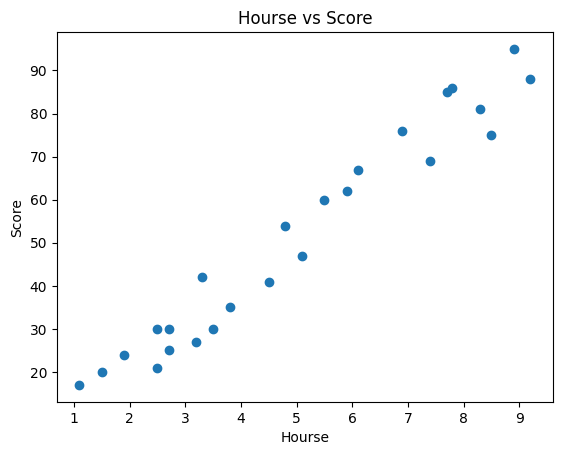

In [ ]:
plt.scatter(x, y)
plt.title("Hourse vs Score")
plt.xlabel("Hourse")
plt.ylabel("Score")
plt.show()

## Separate tarin and test



In [93]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [94]:
print("x_train: {}".format(x_train.shape))
print("x_test: {}".format(x_test.shape))
print("y_train: {}".format(y_train.shape))
print("y_test: {}".format(y_test.shape))

x_train: (20, 1)
x_test: (5, 1)
y_train: (20,)
y_test: (5,)


## Train

In [103]:
mdl = LinearRegression()
mdl.fit(x_train, y_train)

LinearRegression()

In [107]:
print("w:", mdl.coef_)
print("b:", mdl.intercept_)
print("y={:.2f}x + {:.2f}".format(mdl.coef_[0], mdl.intercept_))

w: [9.68207815]
b: 2.826892353899737
y=9.68x + 2.83


## Chart : Regresion

In [97]:
y_t = w * x + b
df_t = pd.DataFrame({"x": x.iloc[:, 0], "y": y, "y_t": y_t.iloc[:, 0]})

In [98]:
print(df_t.head(5))

     x   y        y_t
0  2.5  21  27.032088
1  5.1  47  52.205491
2  3.2  27  33.809542
3  8.5  75  85.124557
4  3.5  30  36.714166


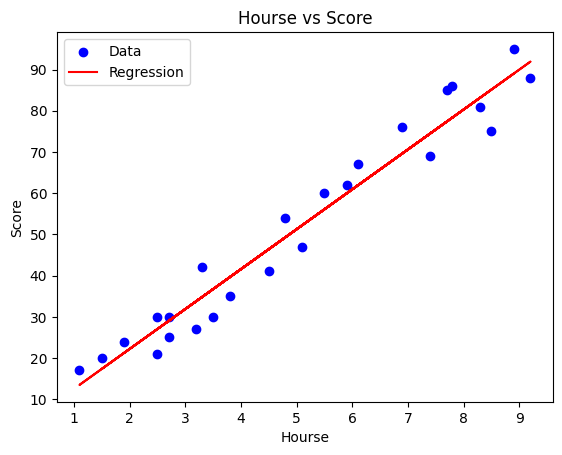

In [99]:
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_t, color='red', label='Regression')
plt.title("Hourse vs Score")
plt.xlabel("Hourse")
plt.ylabel("Score")
plt.legend()
plt.show()

## Predict

In [100]:
y_pred = mdl.predict(x_test)
df_p = pd.DataFrame({"x": x_test.iloc[:, 0], "y": y_test, "y_p": y_pred})
print(df_p)

      x   y        y_p
8   8.3  81  83.188141
16  2.5  30  27.032088
0   2.5  21  27.032088
23  6.9  76  69.633232
11  5.9  62  59.951153


## Evaluation

In [101]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MSE: 18.943211722315272
MAE: 3.9207511902099244
RMSE: 4.352380006653288
